# Grad-CAM Visualization

This notebook visualizes the regions of an MRI image
that contributed most to the model prediction.

Purpose:

- Explain model decisions
- Improve interpretability
- Highlight suspicious regions

In [1]:
import tensorflow as tf
import numpy as np
import cv2

import matplotlib.pyplot as plt

from tensorflow import keras

In [2]:
model = tf.keras.models.load_model(
    "../models/efficientnet_brain_tumor.keras"
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 4)                   │           5,124 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,064,945 (15.51 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 10,250 (40.04 KB)

In [3]:
class_names = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

In [5]:
image_path = "../datasets/classification/Testing/glioma/Te-gl_1.jpg"

In [6]:
IMG_SIZE = (224,224)

img = tf.keras.utils.load_img(
    image_path,
    target_size=IMG_SIZE
)

img_array = tf.keras.utils.img_to_array(
    img
)

img_array = np.expand_dims(
    img_array,
    axis=0
)

In [7]:
predictions = model.predict(
    img_array
)

predicted_class = np.argmax(
    predictions[0]
)

confidence = np.max(
    predictions[0]
)

print(
    "Prediction:",
    class_names[predicted_class]
)

print(
    "Confidence:",
    round(confidence*100,2),
    "%"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction: pituitary
Confidence: 50.35 %


In [8]:
for layer in model.layers:
    print(layer.name)

input_layer_1
sequential
efficientnetb0
global_average_pooling2d
dropout
dense


In [13]:
base_model = model.get_layer("efficientnetb0")

for layer in reversed(base_model.layers):

    if len(layer.output.shape) == 4:

        print(layer.name)

        break

top_activation


In [14]:
def make_gradcam_heatmap(
    img_array,
    model,
    last_conv_layer_name="top_activation"
):

    base_model = model.get_layer("efficientnetb0")

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            base_model.get_layer(
                last_conv_layer_name
            ).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(
            img_array
        )

        pred_index = tf.argmax(
            predictions[0]
        )

        class_channel = predictions[
            :, pred_index
        ]

    grads = tape.gradient(
        class_channel,
        conv_outputs
    )

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0,1,2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(
        pooled_grads * conv_outputs,
        axis=-1
    )

    heatmap = tf.maximum(
        heatmap,
        0
    )

    heatmap /= (
        tf.reduce_max(heatmap) + 1e-8
    )

    return heatmap.numpy()

In [16]:
print(type(model))

print("Input:")
print(model.input)

print("\nOutput:")
print(model.output)

<class 'keras.src.models.functional.Functional'>
Input:
<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=input_layer_1>

Output:
<KerasTensor shape=(None, 4), dtype=float32, sparse=False, ragged=False, name=keras_tensor_514>


In [17]:
base_model = model.get_layer("efficientnetb0")

print(base_model.input)
print(base_model.output)

<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=input_layer>
<KerasTensor shape=(None, 7, 7, 1280), dtype=float32, sparse=False, ragged=False, name=keras_tensor_504>


In [18]:
for i, layer in enumerate(model.layers):
    print(i, layer.name)

0 input_layer_1
1 sequential
2 efficientnetb0
3 global_average_pooling2d
4 dropout
5 dense


In [19]:
for i, layer in enumerate(base_model.layers[-10:]):
    print(layer.name)

block7a_se_squeeze
block7a_se_reshape
block7a_se_reduce
block7a_se_expand
block7a_se_excite
block7a_project_conv
block7a_project_bn
top_conv
top_bn
top_activation


In [20]:
predictions = model.predict(img_array)

predicted_class = np.argmax(predictions[0])

confidence = np.max(predictions[0])

print(class_names[predicted_class])

print(confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
pituitary
0.5035445


In [21]:
last_conv_layer = base_model.get_layer(
    "top_activation"
)

grad_model = tf.keras.Model(

    inputs=base_model.input,

    outputs=[
        last_conv_layer.output,
        base_model.output
    ]
)

In [22]:
img = tf.keras.utils.load_img(
    image_path,
    target_size=(224,224)
)

img_array = tf.keras.utils.img_to_array(img)

img_array = np.expand_dims(
    img_array,
    axis=0
)

In [23]:
with tf.GradientTape() as tape:

    conv_outputs, predictions = grad_model(
        img_array
    )

    pooled = tf.reduce_mean(
        conv_outputs,
        axis=(1,2)
    )

grads = tape.gradient(
    pooled,
    conv_outputs
)

In [24]:
print("Conv Output Shape:", conv_outputs.shape)

print("Grads Shape:", grads.shape)

Conv Output Shape: (1, 7, 7, 1280)
Grads Shape: (1, 7, 7, 1280)


In [25]:
pooled_grads = tf.reduce_mean(
    grads,
    axis=(0,1,2)
)

conv_outputs = conv_outputs[0]

heatmap = tf.reduce_sum(
    pooled_grads * conv_outputs,
    axis=-1
)

heatmap = tf.maximum(
    heatmap,
    0
)

heatmap = heatmap / (
    tf.reduce_max(heatmap) + 1e-8
)

heatmap = heatmap.numpy()

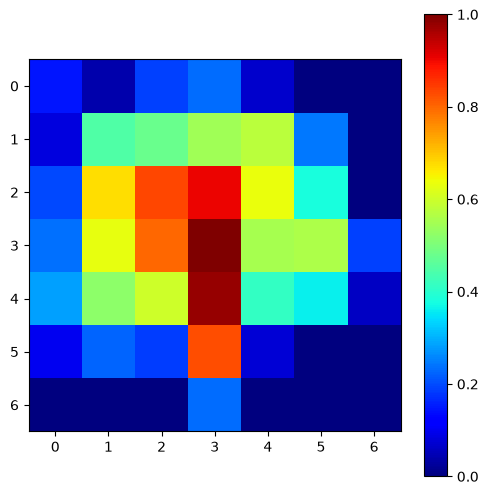

In [26]:
plt.figure(figsize=(6,6))

plt.imshow(
    heatmap,
    cmap="jet"
)

plt.colorbar()

plt.show()

In [27]:
original = cv2.imread(image_path)

original = cv2.cvtColor(
    original,
    cv2.COLOR_BGR2RGB
)

heatmap_resized = cv2.resize(
    heatmap,
    (
        original.shape[1],
        original.shape[0]
    )
)

heatmap_resized = np.uint8(
    255 * heatmap_resized
)

heatmap_color = cv2.applyColorMap(
    heatmap_resized,
    cv2.COLORMAP_JET
)

heatmap_color = cv2.cvtColor(
    heatmap_color,
    cv2.COLOR_BGR2RGB
)

overlay = cv2.addWeighted(
    original,
    0.6,
    heatmap_color,
    0.4,
    0
)

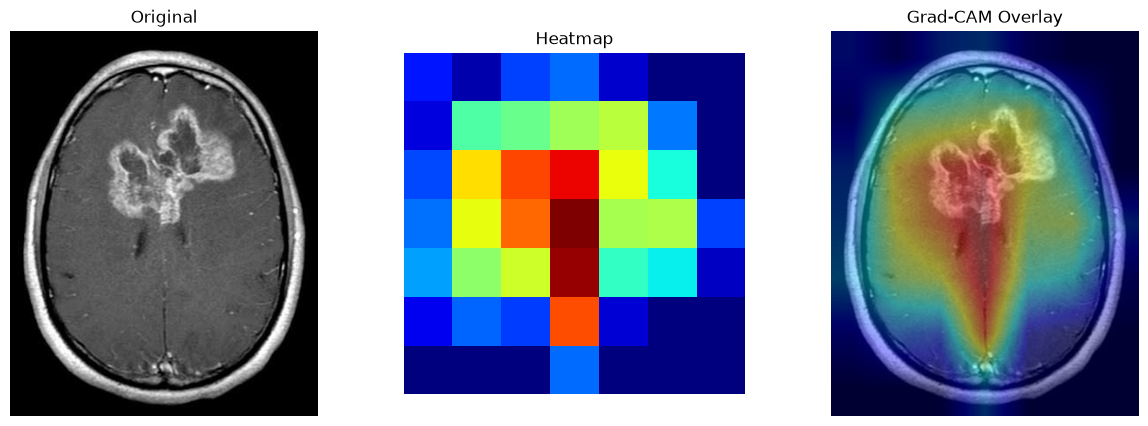

In [28]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(heatmap,cmap="jet")
plt.title("Heatmap")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(overlay)
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.show()

In [29]:
print(conv_outputs.shape)
print(grads.shape)

(7, 7, 1280)
(1, 7, 7, 1280)


In [30]:
plt.imsave(
    "../reports/gradcam_heatmap.png",
    heatmap,
    cmap="jet"
)

plt.imsave(
    "../reports/gradcam_overlay.png",
    overlay
)